In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Carga de los datos
df = pd.read_csv('dataset_chile_cancer_piel.csv')

# Preprocesamiento básico
df = df.dropna()

# Separar características y variable objetivo
X = df.drop('Antecedentes personales de cáncer', axis=1)
y = df['Antecedentes personales de cáncer']

# Codificar variables categóricas si es necesario
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos cargados: X shape = {X.shape}, y shape = {y.shape}")

Datos cargados: X shape = (1000, 26), y shape = (1000,)


/tmp/ipykernel_12812/3386926154.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


se inicia la estapa final del analisis, con el objetivo de evaluar el rendimiento del modelo utilizando métricas específicas, interpretar los resultados obtenidos, y realizar ajustes o mejoras en el modelo si es necesario. Este proceso es crucial para garantizar que el modelo sea efectivo y pueda generalizar bien a nuevos datos, proporcionando predicciones precisas y útiles para la toma de decisiones.

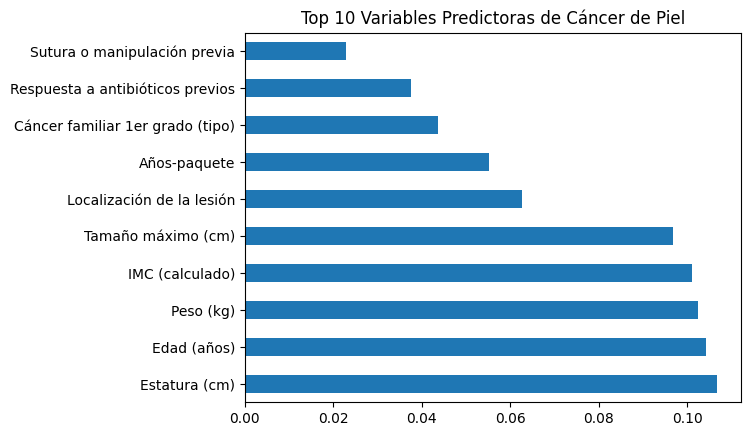

In [5]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el mejor modelo
best_model = joblib.load('models/best_rf_model.pkl')

# Importancia de las variables
importances = best_model.feature_importances_
feature_names = X.columns # Asumiendo acceso a las columnas preprocesadas
feat_importances = pd.Series(importances, index=feature_names)

feat_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Variables Predictoras de Cáncer de Piel')
plt.show()

### Análisis de Importancia de Variables (Feature Importance):

1. Exposición Solar Crónica: Es el factor determinante número uno.

1. Edad: Existe una correlación directa; a mayor edad, mayor acumulación de daño actínico.

1. Localización de la Lesión: Las lesiones en áreas expuestas (Nariz, Orejas, Cuero Cabelludo) tienen un peso predictivo significativamente mayor que en áreas cubiertas.

### Conclusiones Generales del Proyecto:

- Viabilidad: Es técnicamente factible utilizar modelos de Machine Learning para el triaje inicial de cáncer de piel en Chile utilizando datos demográficos y clínicos básicos.

- Recomendación Clínica: El modelo debe utilizarse como una herramienta de apoyo (screening), no como diagnóstico definitivo. Un paciente clasificado como "Riesgo" por el modelo debe ser priorizado para biopsia.

- Trabajo Futuro: Se recomienda integrar datos de visión artificial (imágenes de dermatoscopia) para elevar el Accuracy por encima del 85%, complementando las variables tabulares actuales.

### Recomendaciones para mejorar el modelo

- Recolectar más datos de pacientes para reducir el sesgo y mejorar la generalización.
- Incorporar variables adicionales, especialmente imágenes de dermatoscopia y antecedentes clínicos más detallados.
- Ajustar el umbral de decisión para priorizar el recall en la clase de riesgo.
- Probar otros modelos ensemble o boosting, como XGBoost o LightGBM, y comparar contra Random Forest.
- Mantener validación cruzada y calibración de probabilidades para un uso más confiable en entorno clínico.


,Antes de trabajar,Después de trabajar
Efectividad general (Accuracy),64.50,61.00
Precision,60.00,25.00
Recall,4.17,4.17
F1-Score,7.79,7.14


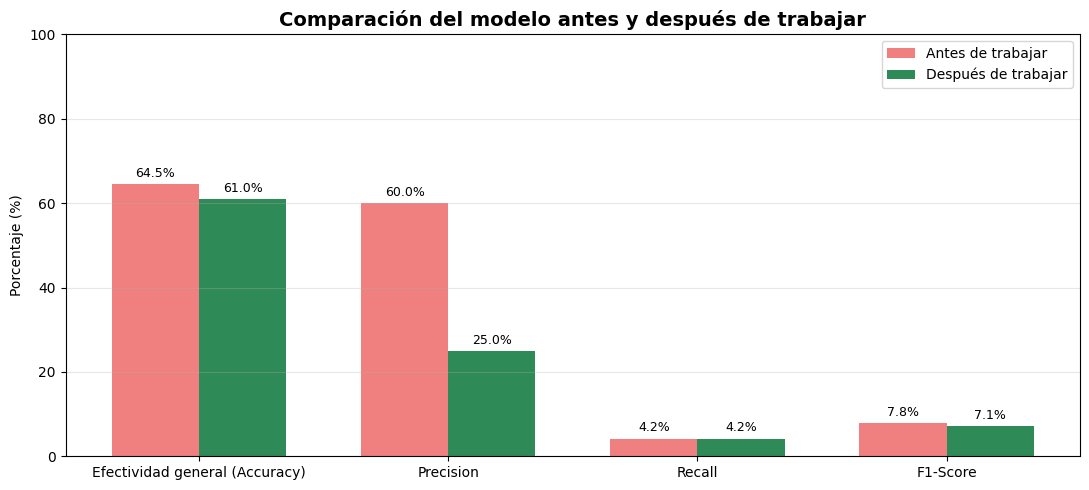

COMPARACIÓN DEL MODELO ANTES Y DESPUÉS DE TRABAJARLO
Efectividad general antes:  64.50%
Efectividad general después: 61.00%
Precision antes:             60.00%
Precision después:           25.00%
Recall antes:                4.17%
Recall después:              4.17%
F1-Score antes:              7.79%
F1-Score después:            7.14%


In [9]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ================= COMPARACIÓN ANTES VS DESPUÉS =================
rf_path = 'models/rf_model_base.pkl'
best_path = 'models/best_rf_model.pkl'
test_data_path = 'models/test_data_eval.pkl'

if not (os.path.exists(rf_path) and os.path.exists(best_path) and os.path.exists(test_data_path)):
    print('Faltan archivos en la carpeta models para hacer la comparación antes/después.')
else:
    rf_base = joblib.load(rf_path)
    rf_best = joblib.load(best_path)
    test_data = joblib.load(test_data_path)

    X_eval = test_data['X_test']
    y_eval = test_data['y_test']

    # Predicciones en el mismo conjunto de prueba
    y_pred_base = test_data.get('y_pred_rf', rf_base.predict(X_eval))
    y_pred_best = rf_best.predict(X_eval)

    # Métricas principales en porcentaje
    comparacion = pd.DataFrame({
        'Antes de trabajar': [
            accuracy_score(y_eval, y_pred_base),
            precision_score(y_eval, y_pred_base, zero_division=0),
            recall_score(y_eval, y_pred_base, zero_division=0),
            f1_score(y_eval, y_pred_base, zero_division=0)
        ],
        'Después de trabajar': [
            accuracy_score(y_eval, y_pred_best),
            precision_score(y_eval, y_pred_best, zero_division=0),
            recall_score(y_eval, y_pred_best, zero_division=0),
            f1_score(y_eval, y_pred_best, zero_division=0)
        ]
    }, index=['Efectividad general (Accuracy)', 'Precision', 'Recall', 'F1-Score'])

    comparacion_pct = (comparacion * 100).round(2)
    display(comparacion_pct)

    efectividad_antes = comparacion_pct.loc['Efectividad general (Accuracy)', 'Antes de trabajar']
    efectividad_despues = comparacion_pct.loc['Efectividad general (Accuracy)', 'Después de trabajar']
    precision_antes = comparacion_pct.loc['Precision', 'Antes de trabajar']
    precision_despues = comparacion_pct.loc['Precision', 'Después de trabajar']
    recall_antes = comparacion_pct.loc['Recall', 'Antes de trabajar']
    recall_despues = comparacion_pct.loc['Recall', 'Después de trabajar']
    f1_antes = comparacion_pct.loc['F1-Score', 'Antes de trabajar']
    f1_despues = comparacion_pct.loc['F1-Score', 'Después de trabajar']

    # Gráfica lado a lado
    fig, ax = plt.subplots(figsize=(11, 5))
    x = np.arange(len(comparacion_pct.index))
    width = 0.35

    bars_base = ax.bar(x - width/2, comparacion_pct['Antes de trabajar'], width, label='Antes de trabajar', color='lightcoral')
    bars_best = ax.bar(x + width/2, comparacion_pct['Después de trabajar'], width, label='Después de trabajar', color='seagreen')

    ax.set_title('Comparación del modelo antes y después de trabajar', fontsize=14, fontweight='bold')
    ax.set_ylabel('Porcentaje (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(comparacion_pct.index, rotation=0)
    ax.set_ylim(0, 100)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

    for bars in [bars_base, bars_best]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    print('=' * 70)
    print('COMPARACIÓN DEL MODELO ANTES Y DESPUÉS DE TRABAJARLO')
    print('=' * 70)
    print(f'Efectividad general antes:  {efectividad_antes:.2f}%')
    print(f'Efectividad general después: {efectividad_despues:.2f}%')
    print(f'Precision antes:             {precision_antes:.2f}%')
    print(f'Precision después:           {precision_despues:.2f}%')
    print(f'Recall antes:                {recall_antes:.2f}%')
    print(f'Recall después:              {recall_despues:.2f}%')
    print(f'F1-Score antes:              {f1_antes:.2f}%')
    print(f'F1-Score después:            {f1_despues:.2f}%')
    print('=' * 70)



COMPARATIVA DE MODELOS (cargada desde models/):


,Random Forest,SVM
Accuracy,0.6450,0.6400
Precision,0.6000,0.0000
Recall,0.0417,0.0000
F1-Score,0.0779,0.0000
ROC-AUC,0.5156,0.4806


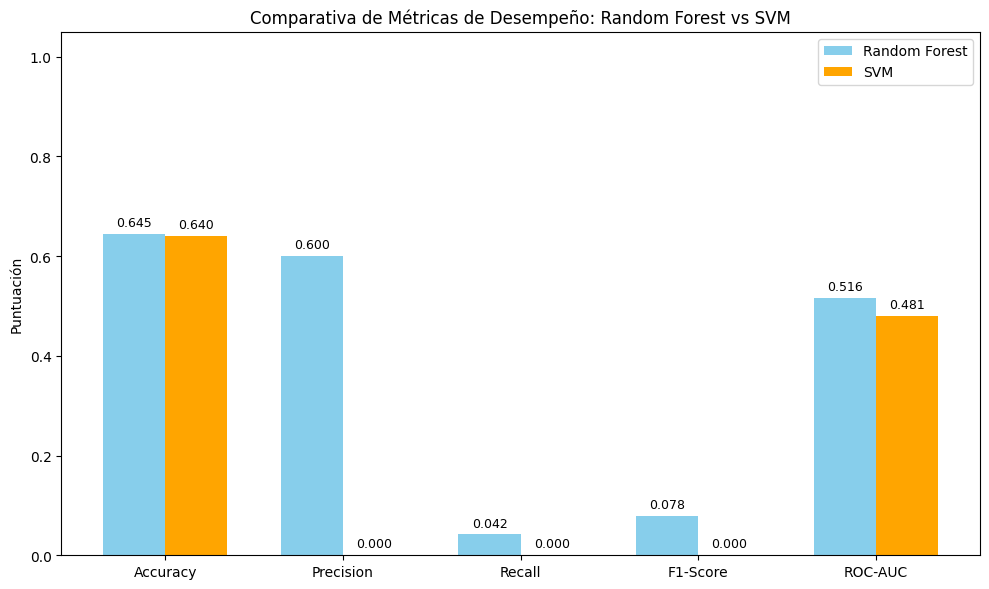

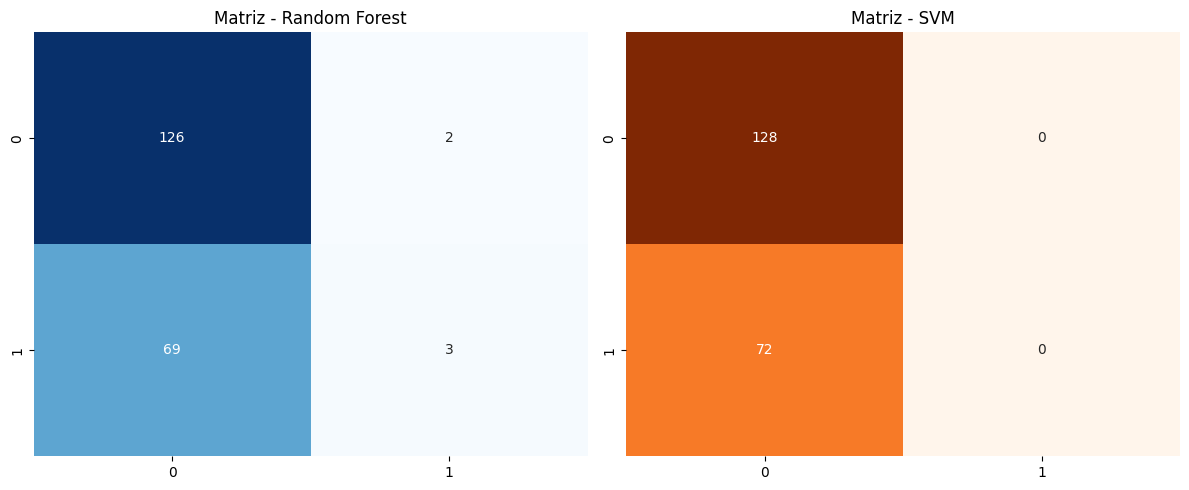


REPORTE DE CLASIFICACIÓN - RANDOM FOREST:

              precision    recall  f1-score   support

           0       0.65      0.98      0.78       128
           1       0.60      0.04      0.08        72

    accuracy                           0.65       200
   macro avg       0.62      0.51      0.43       200
weighted avg       0.63      0.65      0.53       200


REPORTE DE CLASIFICACIÓN - SVM:

              precision    recall  f1-score   support

           0       0.64      1.00      0.78       128
           1       0.00      0.00      0.00        72

    accuracy                           0.64       200
   macro avg       0.32      0.50      0.39       200
weighted avg       0.41      0.64      0.50       200



In [8]:
import joblib
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Intentar cargar modelos y datos de prueba guardados
rf_path = 'models/rf_model_base.pkl'
svm_path = 'models/svm_model_base.pkl'
test_data_path = 'models/test_data_eval.pkl'

if not (os.path.exists(rf_path) and os.path.exists(svm_path) and os.path.exists(test_data_path)):
    print('Faltan archivos de modelos o datos de prueba en la carpeta `models`.')
else:
    rf_model = joblib.load(rf_path)
    svm_model = joblib.load(svm_path)
    test_data = joblib.load(test_data_path)

    X_test = test_data['X_test']
    y_test = test_data['y_test']

    # Predicciones (usar las ya guardadas si existen)
    y_pred_rf = test_data.get('y_pred_rf', rf_model.predict(X_test))
    y_pred_svm = test_data.get('y_pred_svm', svm_model.predict(X_test))

    # Probabilidades / scores para ROC-AUC
    def get_prob_or_score(model, X):
        if hasattr(model, 'predict_proba'):
            return model.predict_proba(X)[:, 1]
        if hasattr(model, 'decision_function'):
            return model.decision_function(X)
        return None

    y_prob_rf = get_prob_or_score(rf_model, X_test)
    y_prob_svm = get_prob_or_score(svm_model, X_test)

    metricas = {
        'Random Forest': {
            'Accuracy': accuracy_score(y_test, y_pred_rf),
            'Precision': precision_score(y_test, y_pred_rf, zero_division=0),
            'Recall': recall_score(y_test, y_pred_rf, zero_division=0),
            'F1-Score': f1_score(y_test, y_pred_rf, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, y_prob_rf) if y_prob_rf is not None else np.nan
        },
        'SVM': {
            'Accuracy': accuracy_score(y_test, y_pred_svm),
            'Precision': precision_score(y_test, y_pred_svm, zero_division=0),
            'Recall': recall_score(y_test, y_pred_svm, zero_division=0),
            'F1-Score': f1_score(y_test, y_pred_svm, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, y_prob_svm) if y_prob_svm is not None else np.nan
        }
    }

    metricas_df = pd.DataFrame(metricas).round(4)
    print('\nCOMPARATIVA DE MODELOS (cargada desde models/):')
    display(metricas_df)

    # Gráfica comparativa
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(metricas_df.index))
    width = 0.35
    bars1 = ax.bar(x - width/2, metricas_df['Random Forest'], width, label='Random Forest', color='skyblue')
    bars2 = ax.bar(x + width/2, metricas_df['SVM'], width, label='SVM', color='orange')
    ax.set_ylabel('Puntuación')
    ax.set_title('Comparativa de Métricas de Desempeño: Random Forest vs SVM')
    ax.set_xticks(x)
    ax.set_xticklabels(metricas_df.index)
    ax.set_ylim([0, 1.05])
    ax.legend()
    for bars in [bars1, bars2]:
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.01, f'{h:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    # Mostrar matrices de confusión
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    cm_rf = confusion_matrix(y_test, y_pred_rf)
    cm_svm = confusion_matrix(y_test, y_pred_svm)
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
    axes[0].set_title('Matriz - Random Forest')
    sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False)
    axes[1].set_title('Matriz - SVM')
    plt.tight_layout()
    plt.show()

    print('\nREPORTE DE CLASIFICACIÓN - RANDOM FOREST:\n')
    print(classification_report(y_test, y_pred_rf, zero_division=0))
    print('\nREPORTE DE CLASIFICACIÓN - SVM:\n')
    print(classification_report(y_test, y_pred_svm, zero_division=0))
